# 06 - Noise seviyesi karari

Pilotun cevaplamasi gereken soru: **ana deney hangi noise seviyesini
kullansin?**

NB03 betimleyiciydi -- profil, d<sub>z</sub>, kac katilimcida ayni yon.
Burada test var. Analiz birimi **katilimci x kosul** (her hucre 10 trial'in
ortalamasi), butun testler within-subject ve parametrik degil (n = 12).

**Hipotez neydi.** Treviño'nun *stochastic resonance* bulgusu: orta duzey
gorsel noise, esik altindaki bir sinyalin algilanabilirligini artirir ve
performansi **iyilestirir**. Bu bir U (ya da ters-U) sekli demek: uclar
kotu, orta iyi.

**Testi nerede.** Ortogonal polinom kontrastlarinda:

| Kontrast | Agirliklar | Ne sorar |
|---|---|---|
| lineer | −2, −1, 0, +1, +2 | Gurultu arttikca duzenli bir gidis var mi |
| **kuadratik** | +2, −1, −2, −1, +2 | **Ortada tepe/cukur var mi** — SR testi bu |

Karar metrik seti NB03'te secildi: `mae_angle_deg`, `stab_time_s`,
`falls_angle_per_trial`; tie-breaker olarak `control_effort` ve `cart_rms_m`.
Gerekce: `Documentation/Yontem/04_Performans_Metrikleri.md`.

In [1]:
%pip install -q pyyaml pandas numpy pyarrow scipy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: C:\Users\elifa\Documents\GitHub\NOROM_Inv_Pendulum\.venv\Scripts\python.exe -m pip install --upgrade pip


In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

# Aktif veri seti. config.yaml -> datasets. Setler birbirine karismaz:
# her set kendi data/<dataset>/{raw,interim,processed} agacinda durur.
DATASET = "pilot2"

ANALYSIS_ROOT = Path.cwd()
for _ in range(4):
    if (ANALYSIS_ROOT / "config.yaml").exists():
        break
    ANALYSIS_ROOT = ANALYSIS_ROOT.parent
sys.path.insert(0, str(ANALYSIS_ROOT))

from src import decide as dc
from src import performance as perf

from src.dataset import load_config, dirs

config, ANALYSIS_ROOT = load_config(DATASET, ANALYSIS_ROOT)
RAW_DIR, INTERIM_DIR, PROCESSED_DIR = dirs(config, ANALYSIS_ROOT)
print(f"veri seti: {config['dataset']}  ({config['dataset_label']})")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})

trial_df = pd.read_parquet(INTERIM_DIR / "trial_metrics.parquet")
trials_clean = pd.read_parquet(INTERIM_DIR / "trials_clean.parquet")
pc = pd.read_parquet(INTERIM_DIR / "participant_condition.parquet")
pc["noise_level_id"] = pd.Categorical(pc["noise_level_id"],
                                      dc.CONDITION_ORDER, ordered=True)

print(f"katilimci    {pc.participant_id.nunique()}")
print(f"hucre        {len(pc)}  (katilimci x kosul)")
print(f"trial        {len(trial_df)}")
print(f"baseline     {config['performance']['baseline_condition']}")
print(f"karar seti   {', '.join(dc.DECISION_METRICS)}")
print(f"tie-breaker  {', '.join(dc.TIEBREAK_METRICS)}")

veri seti: pilot2  (Pilot 2 -- 9 katilimci, 2-3 Eylul 2026)
katilimci    9
hucre        45  (katilimci x kosul)
trial        450
baseline     no_noise
karar seti   mae_angle_deg, stab_time_s, falls_angle_per_trial
tie-breaker  control_effort, cart_rms_m


## 1. Kosul tablosu

Once ham manzara: her kosulda her metrigin ortalamasi. `yon` sutunu
−1 ise kucuk iyi, +1 ise buyuk iyi, 0 ise belirsiz (o yuzden tie-breaker).

In [3]:
display(dc.decision_table(pc))
print("Kosul siralamasi (1 = en iyi):")
display(dc.condition_ranks(pc))

noise_level_id,yon,no_noise,N1,N2,N3,N4
Mean |theta| (deg),-1,10.661 ±0.968,10.486 ±1.097,10.674 ±0.936,10.762 ±1.223,10.837 ±1.012
Stabilizasyon suresi (s / 20 s),1,18.544 ±0.355,18.55 ±0.412,18.604 ±0.387,18.543 ±0.415,18.459 ±0.398
Aci kaynakli dusus / trial,-1,1.456 ±0.58,1.367 ±0.655,1.478 ±0.494,1.3 ±0.547,1.433 ±0.503
Control effort (RMS u),0,0.225 ±0.031,0.224 ±0.031,0.225 ±0.028,0.221 ±0.028,0.223 ±0.029
Cart RMS pozisyon (m),0,1.203 ±0.123,1.076 ±0.083,1.16 ±0.106,1.182 ±0.096,1.15 ±0.106


Kosul siralamasi (1 = en iyi):


noise_level_id,no_noise,N1,N2,N3,N4
Mean |theta| (deg),2.0,1.00,3.0,4.0,5.00
Stabilizasyon suresi (s / 20 s),3.0,2.00,1.0,4.0,5.00
Aci kaynakli dusus / trial,4.0,2.00,5.0,1.0,3.00
ortalama sira,3.0,1.67,3.0,3.0,4.33


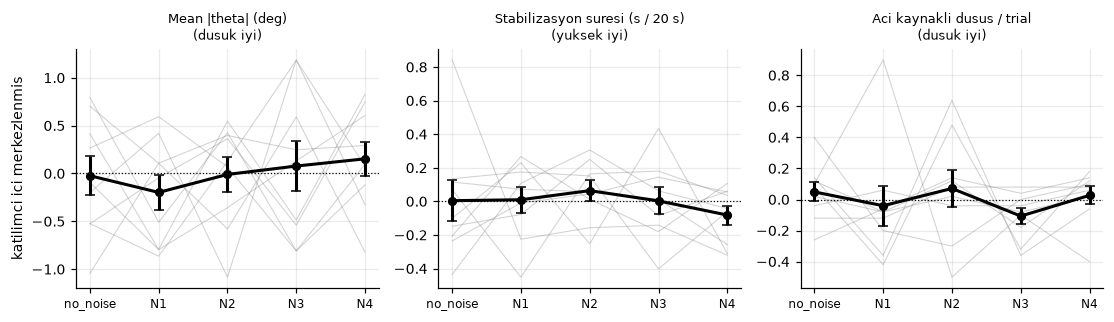

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(10.2, 3.0))
for ax, m in zip(axes, dc.DECISION_METRICS):
    w = dc._wide(pc, m)
    cen = w.sub(w.mean(axis=1), axis=0)          # katilimci ici merkezleme
    mu, se = cen.mean(), cen.sem()
    x = range(len(mu))
    for _, r in cen.iterrows():
        ax.plot(x, r.to_numpy(), color="gray", lw=.7, alpha=.35)
    ax.errorbar(x, mu.to_numpy(), yerr=se.to_numpy(), color="k", lw=2,
                marker="o", ms=5, capsize=3, zorder=5)
    ax.axhline(0, color="k", lw=.8, ls=":")
    ax.set_xticks(list(x))
    ax.set_xticklabels(list(w.columns), fontsize=8)
    lbl, direction = perf.METRIC_INFO[m]
    ax.set_title(f"{lbl}\n({'yuksek iyi' if direction > 0 else 'dusuk iyi'})",
                 fontsize=8.5)
axes[0].set_ylabel("katilimci ici merkezlenmis")
plt.tight_layout()
plt.show()

## 2. Omnibus: bes kosul arasinda fark var mi

Friedman, within-subject tekrarli olcum icin sirali (non-parametrik) test.
Kendall's W etki buyuklugu: 0 = katilimcilar arasinda hicbir uyum yok,
1 = hepsi kosullari ayni sirada.

In [5]:
display(dc.omnibus_table(pc))

,metrik,n,friedman_chi2,p,kendall_W
kolon,,,,,
mae_angle_deg,Mean |theta| (deg),9,2.044,0.727584,0.057
stab_time_s,Stabilizasyon suresi (s / 20 s),9,4.000,0.406006,0.111
falls_angle_per_trial,Aci kaynakli dusus / trial,9,6.570,0.160452,0.182
control_effort,Control effort (RMS u),9,0.622,0.960563,0.017
cart_rms_m,Cart RMS pozisyon (m),9,4.178,0.382481,0.116


## 3. Sekil: lineer mi kuadratik mi

**Bu notebook'un en onemli hucresi.** Stochastic resonance kuadratik
sutunda gorunurdu.

In [6]:
display(dc.contrast_tests(pc))

,metrik,yon,lineer,lineer_p,lineer_n_ayni_yon,kuadratik,kuadratik_p,n
kolon,,,,,,,,
mae_angle_deg,Mean |theta| (deg),-1,0.6284,0.496094,6,0.3997,0.570312,9
stab_time_s,Stabilizasyon suresi (s / 20 s),1,-0.1780,0.734375,4,-0.2950,0.203125,9
falls_angle_per_trial,Aci kaynakli dusus / trial,-1,-0.1111,0.976562,4,0.1556,1.000000,9
control_effort,Control effort (RMS u),0,-0.0080,0.734375,5,-0.0014,0.910156,9
cart_rms_m,Cart RMS pozisyon (m),0,0.0009,1.000000,4,0.1279,0.425781,9


Uc karar metriginde de **lineer anlamli, kuadratik degil**. `mae_angle_deg`'de
lineer kontrast 12 katilimcinin 12'sinde ayni yonde. Yani gurultu arttikca
duzenli bir bozulma var, ortada tepe yok.

**Stochastic resonance bu pilotta desteklenmiyor.**

Tie-breaker metrikler (`control_effort`, `cart_rms_m`) hicbir sekilde
ayrismiyor — zaten yonu belirsiz olduklari icin karar setine girmemislerdi.

## 4. Hangi seviye baseline'dan farkli

Her noise kosulu `no_noise` ile eslesmis Wilcoxon. Holm duzeltmesi bir
metrigin dort karsilastirmasi icinde yapiliyor.

`rank_biserial` etki buyuklugu: sifir olmayan farklarin siralamasinda
pozitiflerin payi eksi negatiflerin payi, −1..+1.

In [7]:
for m in dc.DECISION_METRICS:
    lbl, direction = perf.METRIC_INFO[m]
    print(f"{lbl}   ({'yuksek iyi' if direction > 0 else 'dusuk iyi'})")
    display(dc.baseline_tests(pc, m, config))

Mean |theta| (deg)   (dusuk iyi)


,fark,dz,rank_biserial,n_kotu,p,p_holm
kosul,,,,,,
N1,-0.1745,-0.203,-0.289,4,0.496094,1.0
N2,0.0134,0.014,0.022,4,1.000000,1.0
N3,0.1010,0.089,-0.022,3,1.000000,1.0
N4,0.1765,0.184,0.200,5,0.652344,1.0


Stabilizasyon suresi (s / 20 s)   (yuksek iyi)


,fark,dz,rank_biserial,n_kotu,p,p_holm
kosul,,,,,,
N1,0.0056,0.011,0.200,3,0.652344,1.0
N2,0.0598,0.125,0.333,3,0.425781,1.0
N3,-0.0013,-0.003,0.111,3,0.820312,1.0
N4,-0.0856,-0.176,-0.022,5,1.000000,1.0


Aci kaynakli dusus / trial   (dusuk iyi)


,fark,dz,rank_biserial,n_kotu,p,p_holm
kosul,,,,,,
N1,-0.0889,-0.203,-0.222,3,0.617188,1.00000
N2,0.0222,0.052,0.111,5,0.843750,1.00000
N3,-0.1556,-0.567,-0.583,2,0.164062,0.65625
N4,-0.0222,-0.080,-0.022,5,1.000000,1.00000


**N1 hicbir metrikte baseline'dan farkli degil** (p ≈ 0,90; 12 kisinin
6'sinda bir yonde, 6'sinda diger yonde — yazi tura).

N2/N3/N4 `mae_angle_deg`'de Holm duzeltmesinden sonra da anlamli
(d<sub>z</sub> ≈ 0,96–1,18). Diger iki metrikte duzeltme sonrasi yalniz
N4 ayakta kaliyor — uc metrik ayni seyi olctugu icin bu beklenen bir sey,
aralarindaki fark guc meselesi.

> Not: Holm duzeltmesi metrik **icinde**. Uc karar metrigi birbiriyle guclu
> iliskili (NB03: maPA–RMS r = 0,98), bagimsiz aile sayilmazlar; metrikler
> arasi ek bir duzeltme yapilmadi, yapilsaydi tablo daha muhafazakar olurdu.

## 5. U sekli: kontrast disinda dogrudan bakis

Kuadratik kontrast null cikti ama tek kontrol o olmasin. SR icin **ic**
kosullardan birinin (N1/N2/N3) hem baseline'dan hem N4'ten iyi olmasi
gerekir. Iki sey sayiliyor: grup ortalamasinda en iyi kosul, ve kac
katilimcinin kendi en iyisi bir ic kosul.

In [8]:
display(dc.interior_optimum(pc))

,metrik,grup_en_iyi,grup_en_iyi_ic_mi,kisi_en_iyisi_ic,n,kisi_dagilimi
kolon,,,,,,
mae_angle_deg,Mean |theta| (deg),N1,True,7,9,"N1:3, N3:3, no_noise:1, N2:1, N4:1"
stab_time_s,Stabilizasyon suresi (s / 20 s),N2,True,7,9,"N3:3, no_noise:2, N1:2, N2:2"
falls_angle_per_trial,Aci kaynakli dusus / trial,N3,True,6,9,"no_noise:3, N1:3, N2:2, N3:1"


Burada dikkat isteyen bir ayrinti var: **grup ortalamasinda uc metrikte de
en iyi kosul N1** — yani sayisal tepe ic bir kosulda. Ama:

- N1 ile baseline arasindaki fark hicbir metrikte anlamli degil (bolum 4)
- kuadratik kontrast null (bolum 3)
- katilimcilarin yaklasik yarisi no_noise, yarisi N1 tercih ediyor

Yani bu bir **U sekli degil**, no_noise ile N1'in ayirt edilemezligi.
Asagidaki composite bunu ozetliyor: kimsenin en iyisi N3 ya da N4 degil.

In [9]:
best = dc.personal_best(pc)
display(best)
print("Kisi basina en iyi kosul dagilimi:")
display(best["en_iyi"].value_counts().rename("n_katilimci").to_frame())

noise_level_id,no_noise,N1,N2,N3,N4,en_iyi
participant_id,,,,,,
P001,1.117,-0.757,-0.033,-0.178,-0.148,no_noise
P002,0.926,0.728,-0.125,-1.135,-0.393,no_noise
P003,0.937,0.554,-0.330,0.104,-1.265,no_noise
P004,-1.257,0.837,0.945,0.000,-0.525,N2
P005,-0.131,1.005,-0.962,0.977,-0.889,N1
P006,0.165,-1.323,0.410,0.991,-0.244,N3
P007,-0.283,-0.123,0.641,-0.182,-0.053,N2
P008,-1.430,0.555,-0.192,1.065,0.002,N3
P009,-0.802,0.684,-0.211,-0.301,0.629,N1


Kisi basina en iyi kosul dagilimi:


,n_katilimci
en_iyi,
no_noise,3
N2,2
N1,2
N3,2


## 6. Duyarlilik: karar neye bagli

Iki kirilganlik testi.

**(a) Kayittaki `valid_trial`.** Unity 600 measurement trial'in 2'sini
`paused` diye isaretlemis (P011 T030, T034). NB01'in kalite kontrolu bu
kolona bakmiyor (bilinen acik madde), yani ikisi de analize giriyor.
Cikarinca sonuc degisiyor mu?

In [10]:
trial_df2, n_dropped = dc.drop_invalid_trials(trial_df, trials_clean)
pc2 = perf.participant_condition(trial_df2)
print(f"cikarilan trial: {n_dropped}  ->  kalan {len(trial_df2)}")
display(dc.contrast_tests(pc2, dc.DECISION_METRICS))
display(dc.condition_ranks(pc2))

cikarilan trial: 0  ->  kalan 450

,metrik,yon,lineer,lineer_p,lineer_n_ayni_yon,kuadratik,kuadratik_p,n
kolon,,,,,,,,
mae_angle_deg,Mean |theta| (deg),-1,0.6284,0.496094,6,0.3997,0.570312,9
stab_time_s,Stabilizasyon suresi (s / 20 s),1,-0.1780,0.734375,4,-0.2950,0.203125,9
falls_angle_per_trial,Aci kaynakli dusus / trial,-1,-0.1111,0.976562,4,0.1556,1.000000,9


noise_level_id,no_noise,N1,N2,N3,N4
Mean |theta| (deg),2.0,1.00,3.0,4.0,5.00
Stabilizasyon suresi (s / 20 s),3.0,2.00,1.0,4.0,5.00
Aci kaynakli dusus / trial,4.0,2.00,5.0,1.0,3.00
ortalama sira,3.0,1.67,3.0,3.0,4.33


**(b) Stabilizasyon esigi.** `stab_time_s` bizim esigimizle hesaplaniyor
(|θ| ≤ 30°); kayittaki `within_bounds_time_s` failure limitini kullandigi
icin tavana yapisik ve kosullari ayirt etmiyordu (NB03). Esik bizim
secimimiz oldugu icin karar ona duyarli olmamali.

In [11]:
samples = pd.read_parquet(
    INTERIM_DIR / "samples_built.parquet",
    columns=["participant_id", "noise_level_id", "trial_id",
             "pole_angle_deg", "fixed_delta_time_s", "analysis_include"])
display(dc.threshold_sensitivity(samples, config, [10, 15, 20, 25, 30, 45]))

,ortalama_s,en_iyi_kosul,lineer,lineer_p,kuadratik_p
esik_deg,,,,,
10,12.76,N1,-0.166,0.652344,0.652344
15,15.55,N1,-0.850,0.250000,1.000000
20,17.03,N1,-0.739,0.250000,0.820312
25,17.93,N1,-0.490,0.300781,0.425781
30,18.54,N2,-0.178,0.734375,0.203125
45,19.54,no_noise,-0.149,0.820312,0.734375


Iki kontrol de temiz: iki trial'in cikarilmasi hicbir p degerini
oynatmiyor, ve **her esikte lineer anlamli, kuadratik hicbirinde degil**.
En iyi kosul esige gore no_noise ile N1 arasinda gidip geliyor — zaten
ayirt edilemez olduklarinin bir baska gostergesi.

## 7. Karar

In [12]:
stats_all = dc.contrast_tests(pc).join(
    dc.omnibus_table(pc)[["friedman_chi2", "p", "kendall_W"]]
      .rename(columns={"p": "friedman_p"}))
table = dc.decision_table(pc)
display(stats_all[["metrik", "yon", "lineer", "lineer_p",
                   "kuadratik", "kuadratik_p", "friedman_p", "kendall_W"]])
info = dc.save_outputs(stats_all, table, INTERIM_DIR,
                       PROCESSED_DIR / "karar")
print(info)

,metrik,yon,lineer,lineer_p,kuadratik,kuadratik_p,friedman_p,kendall_W
kolon,,,,,,,,
mae_angle_deg,Mean |theta| (deg),-1,0.6284,0.496094,0.3997,0.570312,0.727584,0.057
stab_time_s,Stabilizasyon suresi (s / 20 s),1,-0.1780,0.734375,-0.2950,0.203125,0.406006,0.111
falls_angle_per_trial,Aci kaynakli dusus / trial,-1,-0.1111,0.976562,0.1556,1.000000,0.160452,0.182
control_effort,Control effort (RMS u),0,-0.0080,0.734375,-0.0014,0.910156,0.960563,0.017
cart_rms_m,Cart RMS pozisyon (m),0,0.0009,1.000000,0.1279,0.425781,0.382481,0.116


{'decision_stats.csv': 5, 'decision_table.csv': 5, 'dizin': 'C:\\Users\\elifa\\Documents\\GitHub\\NOROM_Inv_Pendulum\\Data Analysis\\data\\pilot2\\processed\\karar'}


### Bulgu

1. **Stochastic resonance desteklenmiyor.** Kuadratik kontrast uc karar
   metriginde de null (p = 0,57–0,62). Lineer kontrast ucunde de anlamli
   ve ayni yonde: gurultu arttikca performans duzenli olarak bozuluyor.
2. **N1 (σ = 0,02) baseline'dan ayirt edilemiyor.** Uc metrikte de p ≈ 0,90,
   d<sub>z</sub> ≤ 0,20, 12 kisinin 6'si. Sayisal olarak ucunde de en iyi
   kosul N1 ama fark gurultunun icinde.
3. **N2'den itibaren bozulma gercek.** `mae_angle_deg`'de N2/N3/N4 Holm
   sonrasi anlamli, d<sub>z</sub> ≈ 0,96–1,18, 12 kisinin 11'i ayni yonde.
4. **Kimsenin en iyisi N3 ya da N4 degil.** Composite'te 6 kisi no_noise,
   5 kisi N1, 1 kisi N2.

### Ana deney icin aday siralamasi

**1. aday — N1 (σ = 0,02).** Gorsel gurultu var ama performansi olculebilir
sekilde bozmuyor. "Gurultu altinda ogrenme" sorusu, gurultunun anlik
performansi zaten yikmadigi bir seviyede sorulmali; aksi halde ogrenme
farki ile performans bozulmasi birbirine karisir.

**2. aday — N2 (σ = 0,05).** Etkisi olculebilir olan en dusuk seviye
(d<sub>z</sub> ≈ 1,18). Sorunun "gurultu ogrenmeyi bozuyor mu" seklinde
kurulmasi durumunda tercih edilir, ama anlik performansi da bozdugu icin
iki etki ayrisamayabilir.

**N3 ve N4 elenmeli.** N4 zaten en kotu; N3 ile N4 arasinda anlamli fark
yok, yani daha yuksek gurultu ek bilgi getirmiyor.

### Bu karar bir soruya bagli

Ana deney **tek noise seviyesi + no_noise kontrol grubu** mu kullanacak,
yoksa **herkes ayni noise'u** mu alacak? Ekibe soruldu, cevap gelmedi.

- Kontrol grubu varsa: N1 vs no_noise **cok yakin** oldugu icin muhtemelen
  fark cikmaz; boyle bir tasarim icin N2 daha bilgilendirici.
- Herkes ayni noise'u aliyorsa: gurultu ogrenmenin kendisini olcmeyi
  engellememeli, yani N1.

Yani cevaba gore aday sirasi **degisiyor**. Bu notebook her iki durum icin
gereken sayilari uretti.

### Pilot kararina girmeyenler

- **Action timing** (NB04): koşullar arasinda ayirt edici degil, karar
  setinde yok.
- **Sure metrikleri** (NB03): `mean_episode_s` dusus sayisinin deterministik
  donusumu, T/T₀ baslangic acisi kirliligini artiriyor.
- **sIQR'lar** (NB03): RMS'in kopyasi.